# **0. Imbalanced Data & Modeling**


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from src.data_loader import load_telco, split_features_target
from src.preprocessing import build_full_pipeline
from src.split_and_imbalance import split_data, compare_imbalance_strategies
from src.evaluate import (
    compute_all_metrics, print_metrics,
    plot_confusion_matrix, plot_roc_pr_curves,
    plot_metrics_comparison, plot_threshold_analysis,
)

IMAGES = "../images"

df = load_telco("../data/Telco-Customer-Churn.csv")
X_raw, y = split_features_target(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_raw, y)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Churn rate — train: {y_train.mean():.1%} | val: {y_val.mean():.1%} | test: {y_test.mean():.1%}")

Train: (4225, 19) | Val: (1409, 19) | Test: (1409, 19)
Churn rate — train: 26.5% | val: 26.5% | test: 26.5%


## **1. Why is accuracy ineffective?**

In [4]:
dummy_pred = np.zeros(len(y_test), dtype=int)
dummy_acc  = (dummy_pred == y_test).mean()

print(f"  Accuracy : {dummy_acc:.1%}  <- high but meaningless")
print("-> Must use Precision/Recall/F1/AUC instead of Accuracy for this imbalanced problem")

  Accuracy : 73.5%  <- high but meaningless
-> Must use Precision/Recall/F1/AUC instead of Accuracy for this imbalanced problem


## **2. Comparing imbalance-handling strategies**


In [5]:
from sklearn.pipeline import Pipeline
from src.preprocessing import ChurnFeatureEngineer, build_preprocessor

encoder = Pipeline([("features", ChurnFeatureEngineer()), ("preprocess", build_preprocessor())])
X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc   = encoder.transform(X_val)

strategies = compare_imbalance_strategies(X_train_enc, y_train)

strategy_results = {}
for strategy_name, (X_s, y_s) in strategies.items():
    print(f"\n--- {strategy_name} ---")
    print(f"  Train distribution: {pd.Series(y_s).value_counts().to_dict()}")

    if strategy_name == "Original (imbalanced)":
        model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    else:
        model = LogisticRegression(max_iter=1000, random_state=42)

    model.fit(X_s, y_s)
    y_prob = model.predict_proba(X_val_enc)[:, 1]
    y_pred = model.predict(X_val_enc)
    metrics = compute_all_metrics(y_val, y_pred, y_prob)
    strategy_results[strategy_name] = metrics
    print_metrics(metrics, strategy_name)


--- Original (imbalanced) ---
  Train distribution: {0: 3104, 1: 1121}

  Original (imbalanced)
  Accuracy    : 0.745  ██████████████
  Precision   : 0.512  ██████████
  Recall      : 0.829  ████████████████
  F1          : 0.633  ████████████
  AUC-ROC     : 0.862  █████████████████
  PR-AUC      : 0.690  █████████████

--- SMOTE ---
  Train distribution: {0: 3104, 1: 3104}

  SMOTE
  Accuracy    : 0.747  ██████████████
  Precision   : 0.515  ██████████
  Recall      : 0.824  ████████████████
  F1          : 0.634  ████████████
  AUC-ROC     : 0.858  █████████████████
  PR-AUC      : 0.683  █████████████

--- Under-sampling ---
  Train distribution: {0: 1121, 1: 1121}

  Under-sampling
  Accuracy    : 0.747  ██████████████
  Precision   : 0.515  ██████████
  Recall      : 0.853  █████████████████
  F1          : 0.642  ████████████
  AUC-ROC     : 0.862  █████████████████
  PR-AUC      : 0.691  █████████████


In [ ]:
plot_metrics_comparison(
    strategy_results,
    save_path=f"{IMAGES}/imbalanced_strategy_comparison.png",
)

## **3. Train main models**

In [6]:
base_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", C=1.0, max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight="balanced", random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=42, verbosity=0,
    ),
}

models = {name: build_full_pipeline(estimator) for name, estimator in base_models.items()}

In [7]:
all_metrics    = {}
all_probs_val  = {}
fitted_models  = {}

for name, pipeline in models.items():
    print(f"\nTraining {name}...")
    pipeline.fit(X_train, y_train)

    y_prob = pipeline.predict_proba(X_val)[:, 1]
    y_pred = pipeline.predict(X_val)

    metrics = compute_all_metrics(y_val, y_pred, y_prob)
    all_metrics[name]   = metrics
    all_probs_val[name] = y_prob
    fitted_models[name] = pipeline

    print_metrics(metrics, name)


Training Logistic Regression...

  Logistic Regression
  Accuracy    : 0.745  ██████████████
  Precision   : 0.512  ██████████
  Recall      : 0.829  ████████████████
  F1          : 0.633  ████████████
  AUC-ROC     : 0.862  █████████████████
  PR-AUC      : 0.690  █████████████

Training Random Forest...

  Random Forest
  Accuracy    : 0.784  ███████████████
  Precision   : 0.577  ███████████
  Recall      : 0.698  █████████████
  F1          : 0.632  ████████████
  AUC-ROC     : 0.854  █████████████████
  PR-AUC      : 0.661  █████████████

Training Gradient Boosting...

  Gradient Boosting
  Accuracy    : 0.811  ████████████████
  Precision   : 0.680  █████████████
  Recall      : 0.540  ██████████
  F1          : 0.602  ████████████
  AUC-ROC     : 0.853  █████████████████
  PR-AUC      : 0.672  █████████████

Training XGBoost...

  XGBoost
  Accuracy    : 0.751  ███████████████
  Precision   : 0.520  ██████████
  Recall      : 0.794  ███████████████
  F1          : 0.629  █████

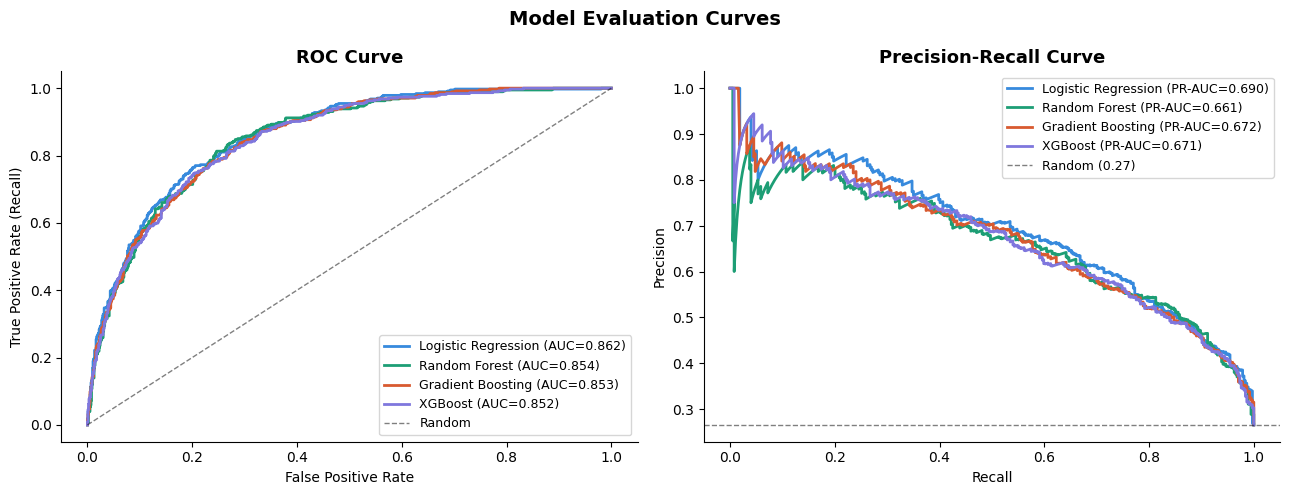

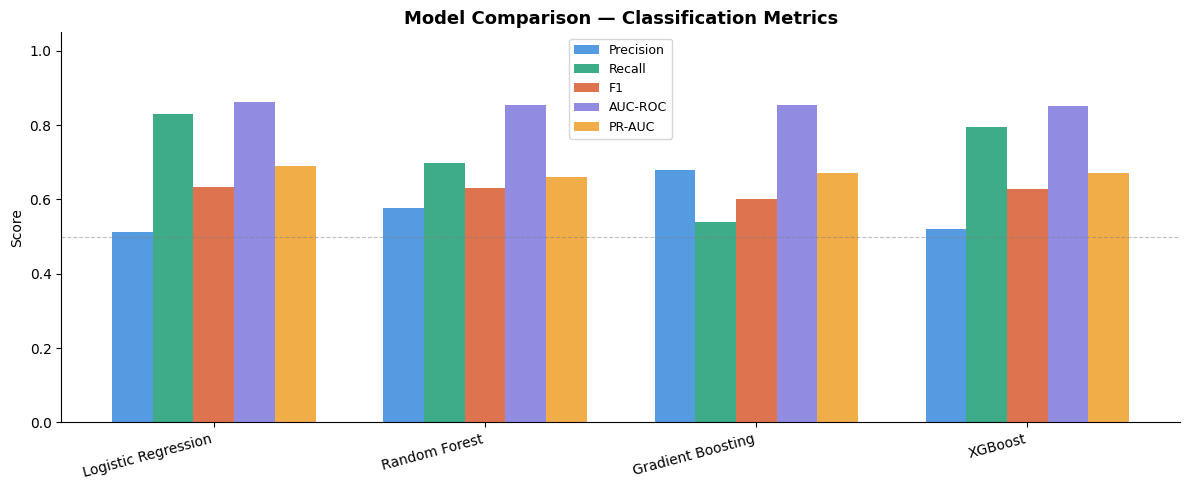


=== Metrics Summary ===
                     Precision  Recall     F1  AUC-ROC  PR-AUC
Logistic Regression      0.512   0.829  0.633    0.862   0.690
Random Forest            0.577   0.698  0.632    0.854   0.661
Gradient Boosting        0.680   0.540  0.602    0.853   0.672
XGBoost                  0.520   0.794  0.629    0.852   0.671


In [8]:
plot_roc_pr_curves(all_probs_val, y_val, save_path=f"{IMAGES}/roc_pr_curves.png")
plot_metrics_comparison(all_metrics, save_path=f"{IMAGES}/model_comparison.png")

## **4. Select the best model and optimize the threshold**


Best model (by Recall): Logistic Regression
Val Recall: 0.829


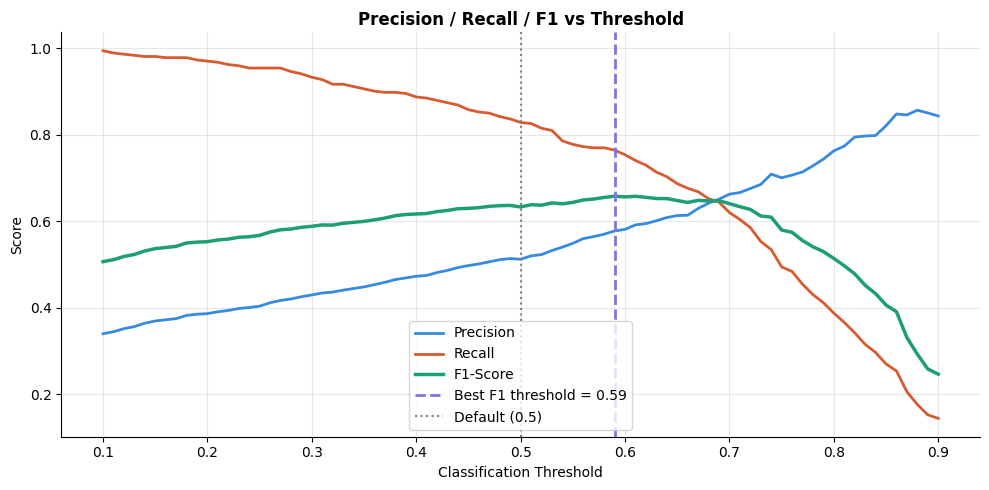


Optimal threshold (from validation set): 0.59
Default threshold: 0.50


In [9]:
SELECTION_METRIC = "Recall" 

best_name  = max(all_metrics, key=lambda k: all_metrics[k][SELECTION_METRIC])
best_model = fitted_models[best_name]

print(f"Best model (by {SELECTION_METRIC}): {best_name}")
print(f"Val {SELECTION_METRIC}: {all_metrics[best_name][SELECTION_METRIC]:.3f}")

best_prob_val = all_probs_val[best_name]
best_threshold = plot_threshold_analysis(
    y_val, best_prob_val,
    save_path=f"{IMAGES}/threshold_analysis.png",
)
print(f"\nOptimal threshold (from validation set): {best_threshold:.2f}")
print("Default threshold: 0.50")

## **5. Final evaluation on test set**

=== Test set, default threshold (0.50) ===

  Accuracy    : 0.740  ██████████████
  Precision   : 0.506  ██████████
  Recall      : 0.802  ████████████████
  F1          : 0.620  ████████████
  AUC-ROC     : 0.839  ████████████████
  PR-AUC      : 0.657  █████████████

=== Test set, tuned threshold (0.59) ===

  Accuracy    : 0.767  ███████████████
  Precision   : 0.546  ██████████
  Recall      : 0.733  ██████████████
  F1          : 0.626  ████████████
  AUC-ROC     : 0.839  ████████████████
  PR-AUC      : 0.657  █████████████


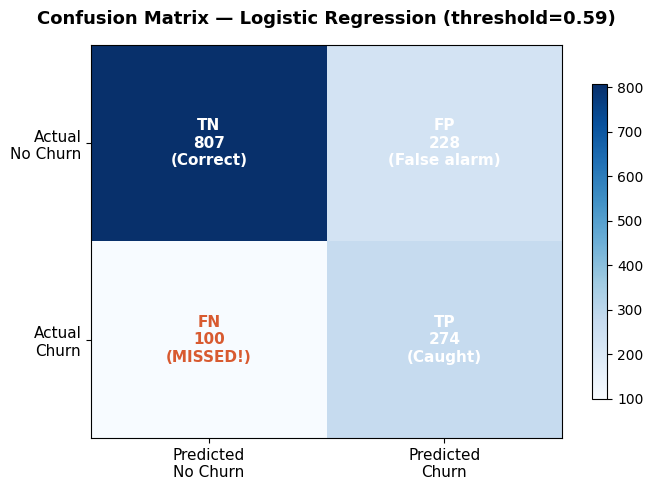


  Recall    = TP/(TP+FN) = 274/374 = 73.3%
  Precision = TP/(TP+FP) = 274/502 = 54.6%
  Missed churners (FN): 100


In [10]:
best_prob_test = best_model.predict_proba(X_test)[:, 1]

y_pred_default = (best_prob_test >= 0.50).astype(int)
y_pred_optimal = (best_prob_test >= best_threshold).astype(int)

metrics_default = compute_all_metrics(y_test, y_pred_default, best_prob_test)
metrics_optimal = compute_all_metrics(y_test, y_pred_optimal, best_prob_test)

print("=== Test set, default threshold (0.50) ===")
print_metrics(metrics_default)
print(f"\n=== Test set, tuned threshold ({best_threshold:.2f}) ===")
print_metrics(metrics_optimal)

plot_confusion_matrix(
    y_test, y_pred_optimal,
    title=f"Confusion Matrix — {best_name} (threshold={best_threshold:.2f})",
    save_path=f"{IMAGES}/confusion_matrix.png",
)

## **6. Save the model**

In [18]:
import joblib

joblib.dump(best_model, "../data/best_model.pkl")
print("\n======Summary======")
print(f"Best Model  : {best_name}")
print(f"Selected by : {SELECTION_METRIC} (val = {all_metrics[best_name][SELECTION_METRIC]:.3f})")
print(f"Test AUC-ROC: {metrics_optimal['AUC-ROC']:.3f}")
print(f"Test Recall : {metrics_optimal['Recall']:.3f}")
print(f"Test F1     : {metrics_optimal['F1']:.3f}")
print(f"Threshold   : {best_threshold:.2f}")



======Summary======
Best Model  : Logistic Regression
Selected by : Recall (val = 0.829)
Test AUC-ROC: 0.839
Test Recall : 0.733
Test F1     : 0.626
Threshold   : 0.59
